# Setup

Import libraries for analysis

In [40]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
from pathlib import Path

from src.images import create_vlm_derivative
from src.lmstudio import (
    analyze_image,
    load_prompt,
    save_result
)
from src.visualization import (
    display_regions,
    compare_regions
)
from src.segmentation import (
    vlm_json_to_regions,
    alto_to_regions
)

from src.alto import load_alto

## Setting

Import model, image, derivative, and segmentation prompt

In [42]:
IMAGE_ID = "1280_AB010309_0005"

DATA = Path("../data")

source = DATA / "images" / f"{IMAGE_ID}.tif"
alto_path = DATA / "alto" / f"{IMAGE_ID}.xml"
derivative = DATA / "derivatives" / f"{IMAGE_ID}.png"

prompt_path = Path("../prompts/segmentation-v1.txt")

MODEL_8B = "qwen3-vl-8b-instruct-mlx"
MODEL_30B = "qwen3-vl-30b-a3b-instruct-mlx"

PROMPT_VERSION = "segmentation-v1"

## Create Derivative

In [43]:
create_vlm_derivative(
    source,
    derivative,
    max_dimension=2048,
)

print(source)
print(derivative)

../data/images/1280_AB010309_0005.tif
../data/derivatives/1280_AB010309_0005.png


## Load Prompt

In [44]:
prompt = load_prompt(prompt_path)

print(prompt)

You are analyzing a historical archival document.

Identify all major visually distinct regions on the page.

Use only these region types:

- main_text
- marginal_text
- stamp_or_seal
- handwritten_annotation
- archival_mark
- illustration
- unknown

Return ONLY valid JSON with this structure:

{
  "regions": [
    {
      "type": "stamp_or_seal",
      "bbox": [x1, y1, x2, y2],
      "confidence": 0.95
    }
  ]
}

Bounding box coordinates must use a normalized coordinate system
from 0 to 1000:

- x=0 is the left edge
- x=1000 is the right edge
- y=0 is the top edge
- y=1000 is the bottom edge

Identify visually observable regions only.

Do not transcribe any text.
Do not identify languages.
Do not determine whether anything is related to waqf.
Do not explain your answer.


## Load eScriptorium baseline

In [50]:
alto = load_alto(alto_path)

escriptorium_regions = alto_to_regions(alto)

print(
    f"eScriptorium regions: "
    f"{len(escriptorium_regions)}"
)

eScriptorium regions: 11


## Inspect baseline

In [52]:
for region in escriptorium_regions:
    print(
        f"{region.region_type:25}",
        region.bbox,
        region.confidence,
    )

main_text                 (125.87959343236903, 279.83832620066573, 884.6755277560594, 552.3062291963862) 0.8283322203030805
main_text                 (257.6231430805317, 113.17165953399905, 375.6841282251759, 132.4298621017594) None
main_text                 (181.00078186082877, 673.323823109843, 491.00860046911646, 718.9728958630528) None
main_text                 (175.52775605942142, 743.2239657631953, 485.5355746677091, 789.1107941036614) None
main_text                 (240.03127443315088, 0.0, 605.9421422986708, 19.020446980504044) None
main_text                 (5.473025801407349, 489.7765097479791, 9.382329945269742, 495.7203994293866) None
main_text                 (0.0, 893.96100808369, 20.32838154808444, 955.777460770328) None
main_text                 (10.946051602814698, 963.1478839752734, 14.855355746677093, 969.091773656681) None
main_text                 (147.77169663799845, 536.6143604374703, 168.49100860046912, 538.9919163100333) None
main_text                 (241.2040

## Qwen 8B

In [53]:
response_8b = analyze_image(
    derivative,
    prompt,
    model=MODEL_8B,
    temperature=0.0,
    max_tokens=4096,
)

print(
    f"Qwen 8B inference: "
    f"{response_8b.elapsed_seconds:.1f}s"
)

Qwen 8B inference: 11.2s


### Parse 8B regions

In [54]:
qwen_8b_regions = vlm_json_to_regions(
    response_8b.parsed,
    source="qwen3-vl-8b",
)

print(
    f"Qwen 8B regions: "
    f"{len(qwen_8b_regions)}"
)

for region in qwen_8b_regions:
    print(
        f"{region.region_type:25}",
        region.bbox,
        region.confidence,
    )

Qwen 8B regions: 9
main_text                 (145.0, 278.0, 873.0, 409.0) 0.95
handwritten_annotation    (173.0, 124.0, 395.0, 186.0) 0.92
handwritten_annotation    (120.0, 467.0, 513.0, 638.0) 0.94
handwritten_annotation    (247.0, 6.0, 619.0, 145.0) 0.93
handwritten_annotation    (128.0, 643.0, 417.0, 720.0) 0.95
stamp_or_seal             (243.0, 391.0, 330.0, 450.0) 0.89
stamp_or_seal             (460.0, 561.0, 700.0, 698.0) 0.92
stamp_or_seal             (201.0, 753.0, 460.0, 793.0) 0.85
archival_mark             (459.0, 907.0, 692.0, 961.0) 0.83


## Save 8B result

In [55]:
result_8b_path = (
    DATA
    / "results"
    / IMAGE_ID
    / "qwen3-vl-8b"
    / f"{PROMPT_VERSION}.json"
)

save_result(
    response_8b,
    result_8b_path,
    task="segmentation",
    prompt_version=PROMPT_VERSION,
)

print(result_8b_path)

../data/results/1280_AB010309_0005/qwen3-vl-8b/segmentation-v1.json


### Visualize 8B

ValueError: Unknown format code 'f' for object of type 'str'

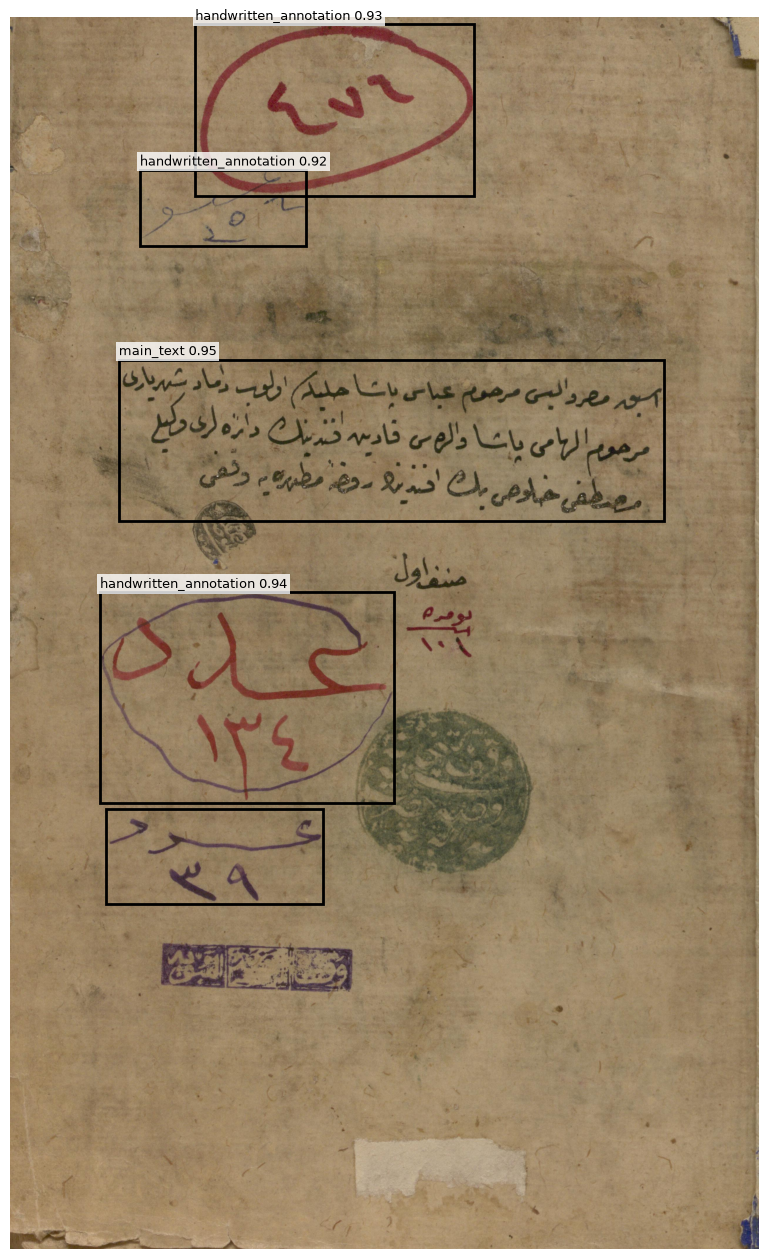

In [56]:
display_regions(
    source,
    qwen_8b_regions,
)

### Against eScriptorium

TypeError: Image data of dtype object cannot be converted to float

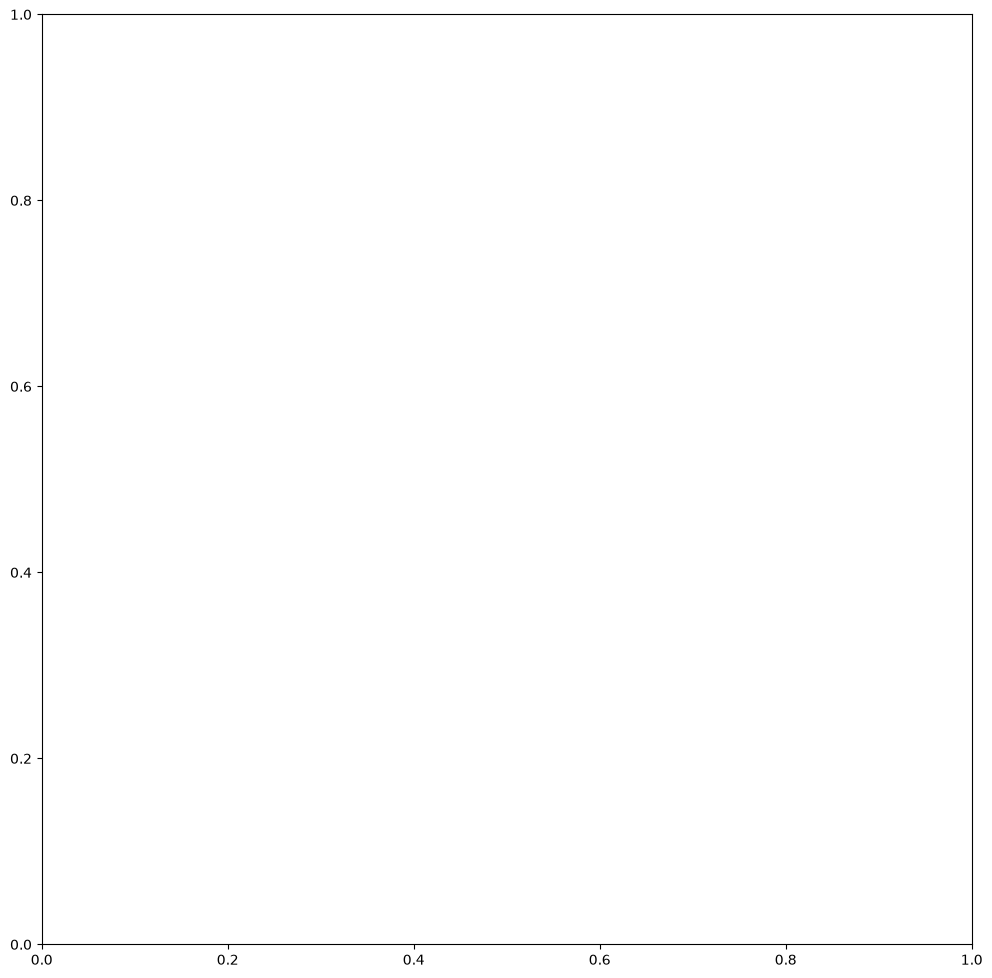

In [57]:
compare_regions(
    source,
    [
        ("eScriptorium", escriptorium_regions),
        ("Qwen 8B", qwen_8b_regions),
    ],
)